In [1]:
import torch
import numpy as np
import random
import os

from transformer_sac.config import *
from transformer_sac.data_loader import load_stocks
from transformer_sac.sac_trainer import SACTrainer
from transformer_sac.backtest import backtest, plot_equity, compute_buyhold_equity

print("Device:", DEVICE)

Device: cuda


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Seed fixed.")

Seed fixed.


In [3]:
train_states, train_prices = load_stocks(mode="train")
val_states, val_prices     = load_stocks(mode="val")
test_states, test_prices   = load_stocks(mode="test")

print("Train files:", len(train_states))
print("Val files:", len(val_states))
print("Test files:", len(test_states))

Train files: 10
Val files: 10
Test files: 10


In [4]:
trainer = SACTrainer()
print("Models initialized.")

Models initialized.


In [5]:
tickers = []

for file in sorted(os.listdir(DATA_FOLDER)):
    if file.endswith(".csv"):
        ticker = file.replace(".csv", "")
        tickers.append(ticker)

print(tickers)

['AAPL', 'AMD', 'AMZN', 'CSCO', 'GOOGL', 'INTC', 'META', 'MSFT', 'NVDA', 'TSLA']


In [6]:
trainer.train(
    train_states=train_states,
    train_prices=train_prices,
    tickers=tickers,
    val_states=val_states,
    val_prices=val_prices
)

Training Started
Episode 1/30
  MSFT       Final Value: 0.6131
    Action 0:  31.8%
    Action 1:  34.4%
    Action 2:  33.8%
  CSCO       Final Value: 0.5703
    Action 0:  31.5%
    Action 1:  36.8%
    Action 2:  31.7%
  AMZN       Final Value: 0.9975
    Action 0:  35.3%
    Action 1:  32.2%
    Action 2:  32.5%
  NVDA       Final Value: 0.9563
    Action 0:  35.3%
    Action 1:  30.9%
    Action 2:  33.8%
  INTC       Final Value: 0.6628
    Action 0:  32.7%
    Action 1:  34.9%
    Action 2:  32.4%
  META       Final Value: 1.2095
    Action 0:  34.4%
    Action 1:  33.1%
    Action 2:  32.5%
  TSLA       Final Value: 1.0690
    Action 0:  33.5%
    Action 1:  31.3%
    Action 2:  35.2%
  GOOGL      Final Value: 0.7416
    Action 0:  36.2%
    Action 1:  32.3%
    Action 2:  31.5%
  AAPL       Final Value: 0.8696
    Action 0:  33.9%
    Action 1:  34.7%
    Action 2:  31.4%
  AMD        Final Value: 0.4309
    Action 0:  36.5%
    Action 1:  30.9%
    Action 2:  32.6%
Average fi

In [7]:
best_model = SACTrainer()

best_model.actor.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
)

best_model.actor.to(DEVICE)
best_model.actor.eval()

print("Best model loaded.")

Best model loaded.


Average Return: 32.4716%
AAPL
------------------------------------------------------------
Total Return: 11.5877%
Win Rate:     40.33%
Final Value:  111587.695312

Action Distribution:
  ALLOC_0    Count:  113 |  26.65%
  ALLOC_35   Count:   70 |  16.51%
  ALLOC_70   Count:  241 |  56.84%


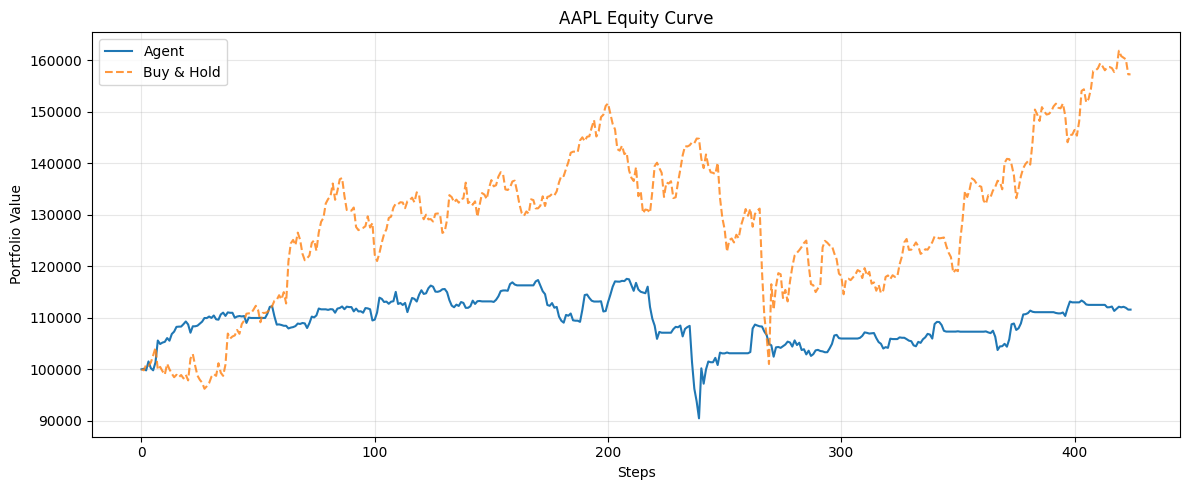

AMD
------------------------------------------------------------
Total Return: 25.1460%
Win Rate:     39.86%
Final Value:  125146.039062

Action Distribution:
  ALLOC_0    Count:   94 |  22.17%
  ALLOC_35   Count:   22 |   5.19%
  ALLOC_70   Count:  308 |  72.64%


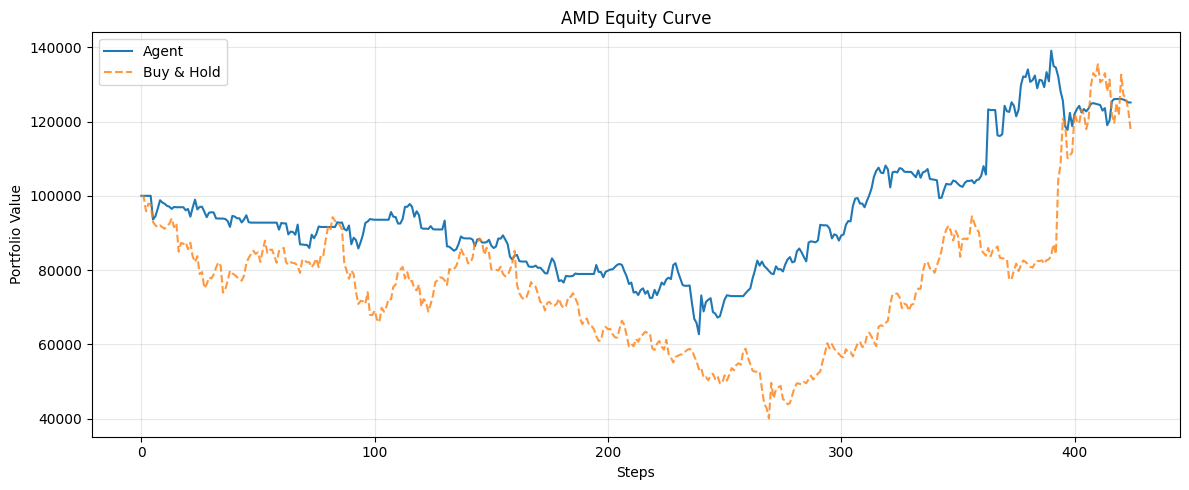

AMZN
------------------------------------------------------------
Total Return: -3.6565%
Win Rate:     38.44%
Final Value:  96343.515625

Action Distribution:
  ALLOC_0    Count:  109 |  25.71%
  ALLOC_35   Count:   74 |  17.45%
  ALLOC_70   Count:  241 |  56.84%


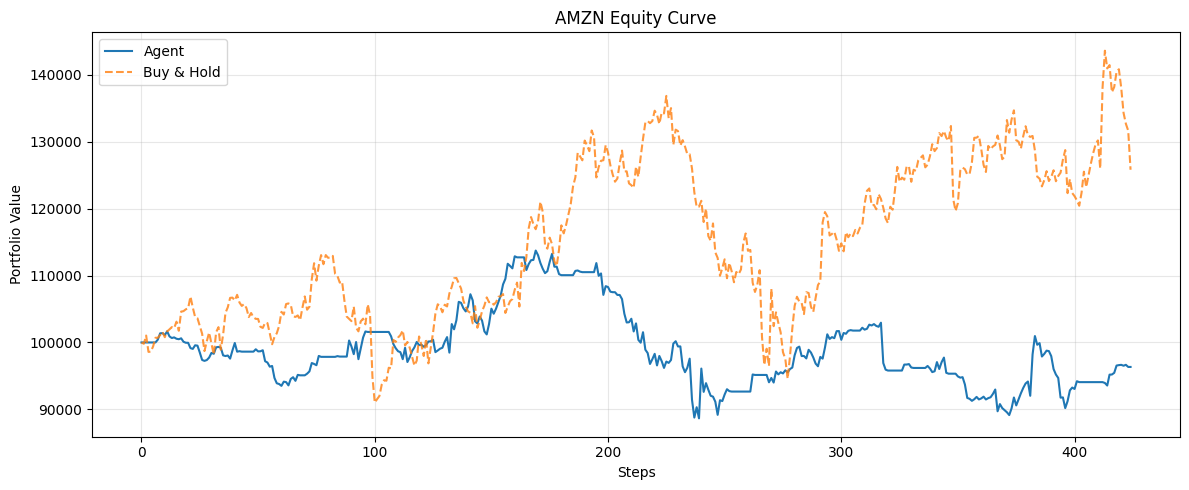

CSCO
------------------------------------------------------------
Total Return: 6.3862%
Win Rate:     42.69%
Final Value:  106386.171875

Action Distribution:
  ALLOC_0    Count:   83 |  19.58%
  ALLOC_35   Count:   56 |  13.21%
  ALLOC_70   Count:  285 |  67.22%


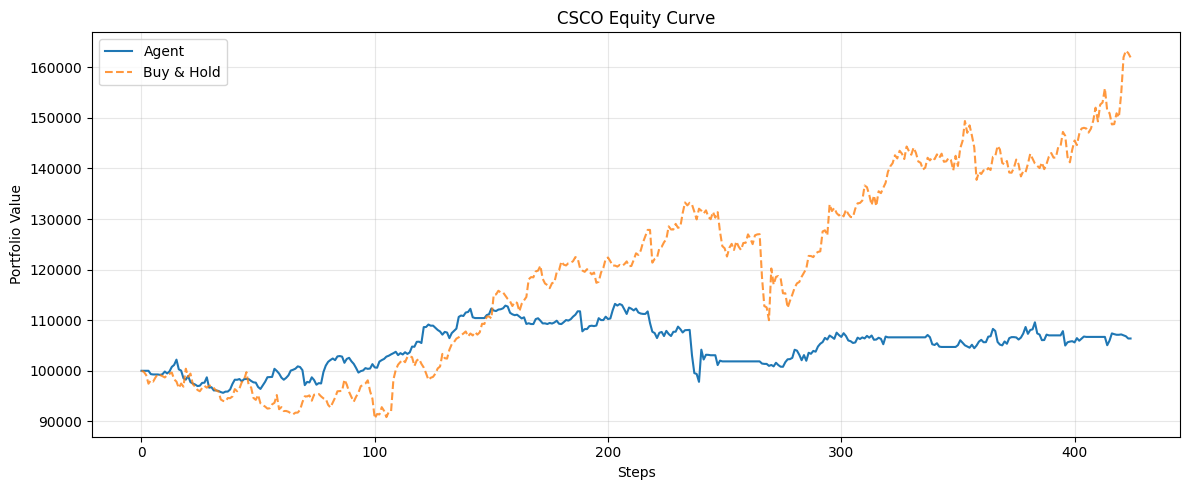

GOOGL
------------------------------------------------------------
Total Return: 49.4662%
Win Rate:     43.63%
Final Value:  149466.203125

Action Distribution:
  ALLOC_0    Count:   93 |  21.93%
  ALLOC_35   Count:   61 |  14.39%
  ALLOC_70   Count:  270 |  63.68%


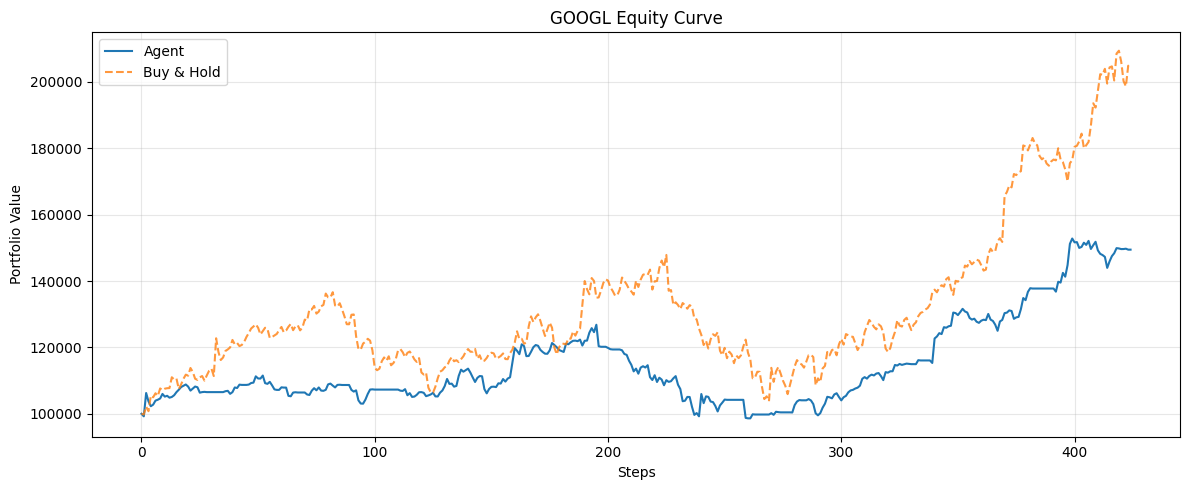

INTC
------------------------------------------------------------
Total Return: 5.3600%
Win Rate:     34.67%
Final Value:  105360.007812

Action Distribution:
  ALLOC_0    Count:  112 |  26.42%
  ALLOC_35   Count:   21 |   4.95%
  ALLOC_70   Count:  291 |  68.63%


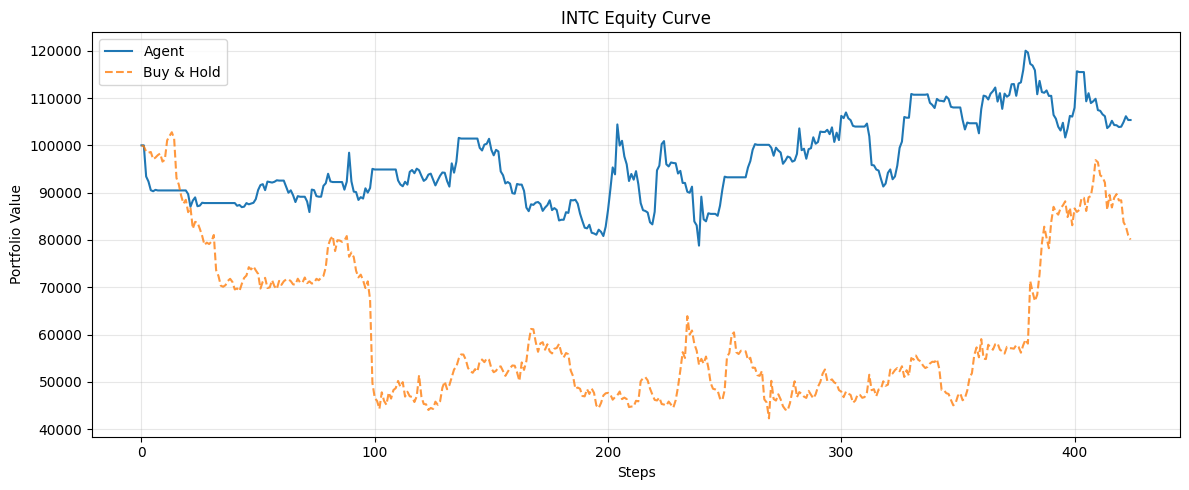

META
------------------------------------------------------------
Total Return: 37.7572%
Win Rate:     43.63%
Final Value:  137757.218750

Action Distribution:
  ALLOC_0    Count:   73 |  17.22%
  ALLOC_35   Count:   36 |   8.49%
  ALLOC_70   Count:  315 |  74.29%


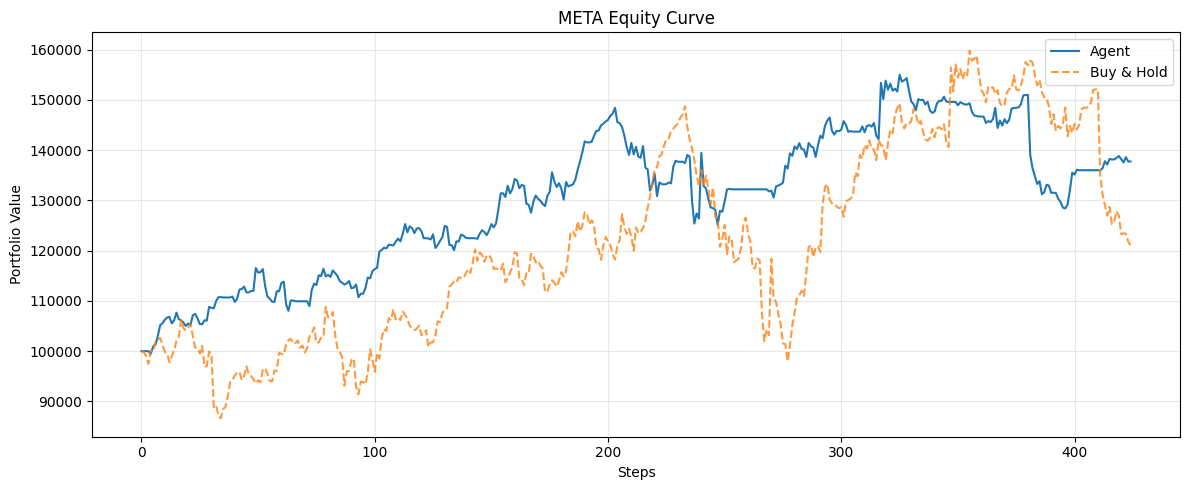

MSFT
------------------------------------------------------------
Total Return: -3.3802%
Win Rate:     42.45%
Final Value:  96619.812500

Action Distribution:
  ALLOC_0    Count:   76 |  17.92%
  ALLOC_35   Count:   89 |  20.99%
  ALLOC_70   Count:  259 |  61.08%


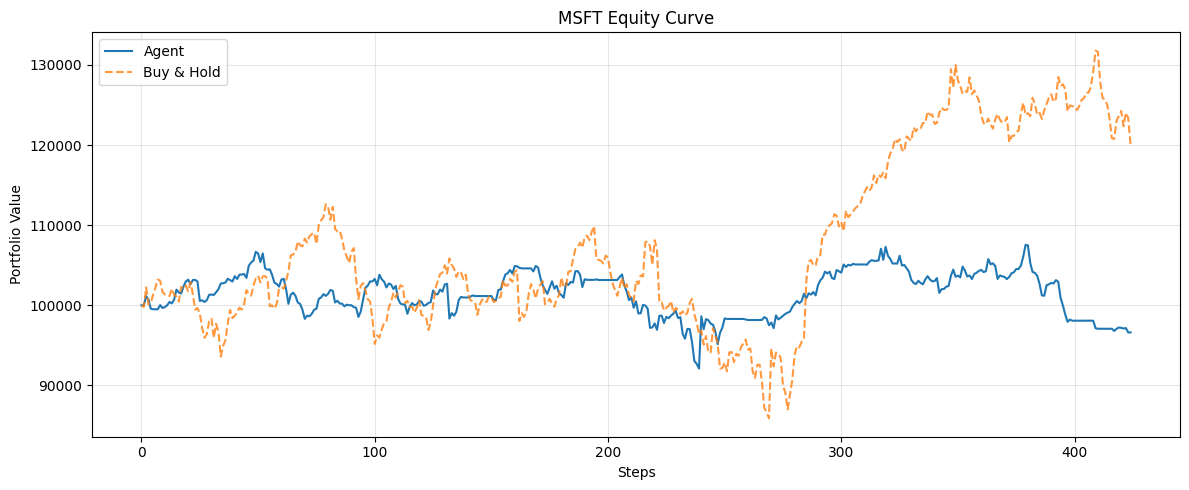

NVDA
------------------------------------------------------------
Total Return: 118.1334%
Win Rate:     42.69%
Final Value:  218133.390625

Action Distribution:
  ALLOC_0    Count:  100 |  23.58%
  ALLOC_35   Count:   27 |   6.37%
  ALLOC_70   Count:  297 |  70.05%


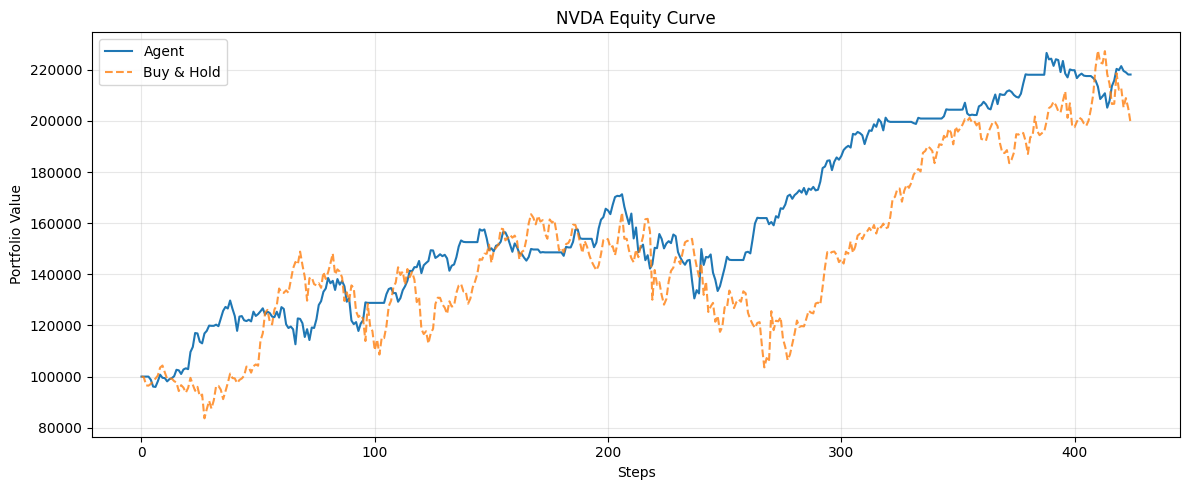

TSLA
------------------------------------------------------------
Total Return: 77.9157%
Win Rate:     37.50%
Final Value:  177915.734375

Action Distribution:
  ALLOC_0    Count:  102 |  24.06%
  ALLOC_35   Count:   11 |   2.59%
  ALLOC_70   Count:  311 |  73.35%


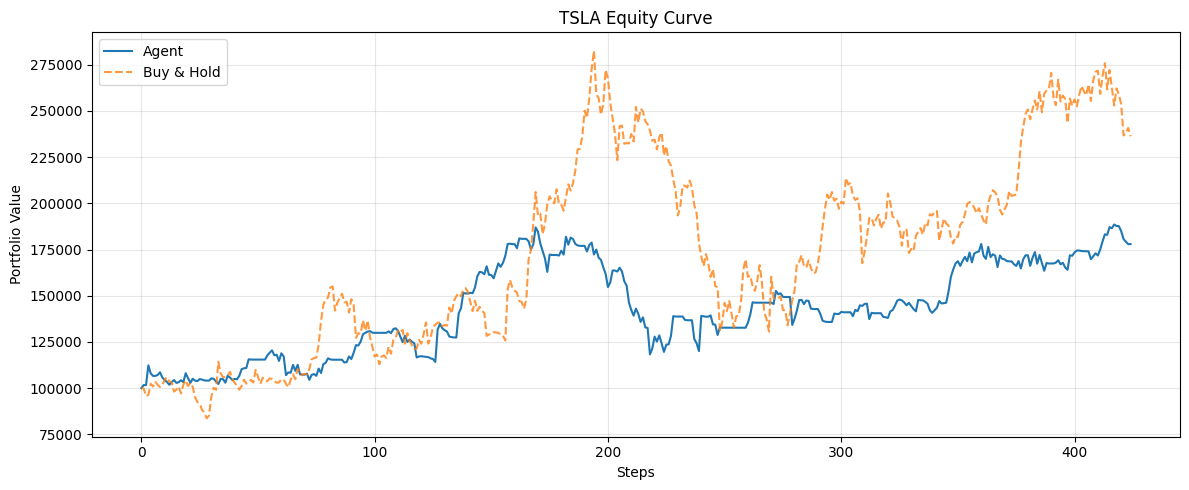

In [8]:
results_best_model = backtest(
    best_model,
    test_states,
    test_prices,
    tickers=tickers,
    steps_per_day=1
)

avg_return = sum(m['Total Return (%)'] for m in results_best_model.values()) / len(results_best_model)
print(f"Average Return: {avg_return:.4f}%")

for i, (ticker, metrics) in enumerate(results_best_model.items()):

    print("="*60)
    print(ticker)
    print("-"*60)

    print(f"Total Return: {metrics['Total Return (%)']:.4f}%")
    print(f"Win Rate:     {metrics['Win Rate (%)']:.2f}%")
    print(f"Final Value:  {metrics['Final Value']:.6f}")

    print("\nAction Distribution:")
    for action_name, stats in metrics["Action Distribution"].items():
        print(
            f"  {action_name:<10} "
            f"Count: {stats['count']:>4} | "
            f"{stats['percentage']:>6.2f}%"
        )

    print("="*60)

    #Buy & Hold Benchmark
    bh_equity = compute_buyhold_equity(test_prices[i])

    # Đảm bảo 2 curve cùng length
    min_len = min(len(metrics["Equity Curve"]), len(bh_equity))

    plot_equity(
        metrics["Equity Curve"][:min_len],
        title=f"{ticker} Equity Curve",
        benchmark=bh_equity[:min_len]
    )